<a href="https://colab.research.google.com/github/mena-04/DoS-Stress-Testing/blob/main/integration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Fri Sep 11 15:44:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip uninstall -y torch torchvision torchaudio vllm
!pip install -q -U uv
!uv pip install --system vllm --torch-backend=cu130
!pip uninstall -y torchaudio

Found existing installation: torch 2.11.0+cu128
Uninstalling torch-2.11.0+cu128:
  Successfully uninstalled torch-2.11.0+cu128
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.0/20.0 MB 65.6 MB/s eta 0:00:00
Using Python 3.13.15 environment at: /usr
Resolved 197 packages in 1.46s
Prepared 101 packages in 1m 19s
Uninstalled 13 packages in 145ms
Installed 101 packages in 969ms
 + agent-detector==2.0.0
 + anthropic==1.5.0
 + apache-tvm-ffi==0.1.11
 + astor==0.8.1
 + blake3==1.0.9
 + cbor2==6.1.4
 + compressed-tensors==0.17.0
 - cuda-bindings==12.9.7
 + cuda-bindings==13.4.1
 - cuda-core==0.3.2
 + cuda-core==1.2.0
 - cuda-python==12.9.7
 + cuda-python==13.4.1
 + cuda-tile==1.6.0
 - cuda-toolkit==12.8.1
 + cuda

In [1]:
import torch, vllm

print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0))
print("vllm:", vllm.__version__)

torch: 2.13.0+cu130
cuda: True
gpu: Tesla T4
vllm: 0.29.0


In [2]:
!git clone https://github.com/mena-04/DoS-Stress-Testing.git
%cd /content/DoS-Stress-Testing

Cloning into 'DoS-Stress-Testing'...
remote: Enumerating objects: 146, done.
remote: Counting objects: 100% (146/146), done.
remote: Compressing objects: 100% (107/107), done.
remote: Total 146 (delta 44), reused 121 (delta 35), pack-reused 0 (from 0)
Receiving objects: 100% (146/146), 185.83 KiB | 4.76 MiB/s, done.
Resolving deltas: 100% (44/44), done.
/content/DoS-Stress-Testing


In [3]:
!pip install -e .
!pytest tests/ -q

Obtaining file:///content/DoS-Stress-Testing
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for dos-mitigation-gateway (pyproject.toml) ... done
  Created wheel for dos-mitigation-gateway: filename=dos_mitigation_gateway-0.1.0-0.editable-py3-none-any.whl size=3386 sha256=92dba2d7119cf698644a7c03fe0c4adcfe04d536d1e27b6d348591f03bccd51b
  Stored in directory: /tmp/pip-ephem-wheel-cache-kvj05kj7/wheels/06/bf/ba/3f0f9911f66c081925d8eceb04fb98ad5cdfc09adca9878586
Successfully built dos-mitigation-gateway
ImportError while loading conftest '/content/DoS-Stress-Testing/tests/conftest.py'.
tests/conftest.py:3: in <module>
    import pytest_asyncio
E   ModuleNotFoundError: No module named 'pytest_asyncio'


In [4]:
import subprocess

vllm_log = open("/content/vllm.log", "w")

server = subprocess.Popen([
    "vllm", "serve",
    "Qwen/Qwen2.5-0.5B-Instruct",
    "--dtype", "half",
    "--max-model-len", "2048",
    "--gpu-memory-utilization", "0.85",
    "--max-num-seqs", "8",
    "--host", "127.0.0.1",
    "--port", "8000",
], stdout=vllm_log, stderr=subprocess.STDOUT)

print("vLLM PID:", server.pid)

vLLM PID: 9710


In [5]:
import requests, time

for i in range(120):
    try:
        r = requests.get("http://127.0.0.1:8000/health", timeout=1)
        if r.status_code == 200:
            print("vLLM READY")
            break
    except:
        pass

    if server.poll() is not None:
        print("vLLM crashed")
        print(open("/content/vllm.log").read())
        break

    time.sleep(1)

In [7]:
payload = {
    "model": "Qwen/Qwen2.5-0.5B-Instruct",
    "messages": [
        {"role": "user", "content": "Explain what an inference server is."}
    ],
    "max_tokens": 32,
    "temperature": 0
}

r = requests.post(
    "http://127.0.0.1:8000/v1/chat/completions",
    json=payload,
    timeout=60
)

print(r.status_code)
print(r.json()["choices"][0]["message"]["content"])

200
An inference server is a type of machine learning model that processes and analyzes large amounts of data to make predictions or decisions based on patterns and relationships within the data.


In [8]:
%%writefile /content/DoS-Stress-Testing/configs/ratelimit_queue_t4.yaml

mode: ratelimit_queue

upstream:
  base_url: http://127.0.0.1:8000

rate_limit:
  requests_per_sec: 5.0
  requests_burst: 10.0
  tokens_per_sec: 2000.0
  tokens_burst: 8000.0
  client_max_inflight: 4
  max_tokens_ceiling: 1024

backpressure:
  global_max_inflight: 8
  upstream_max_num_seqs: 8
  queue_wait_ms: 200

  reserved_cheap_slots: 2
  cheap_cost_threshold: 512

  upstream_waiting_high: 6.0
  upstream_waiting_low: 2.0

  occupancy_high: 0.9
  occupancy_low: 0.6

fairshare:
  window_s: 10.0
  share_multiplier: 1.25
  grace_cost_share: 0.15

logging:
  run_id: mitigated

Writing /content/DoS-Stress-Testing/configs/ratelimit_queue_t4.yaml


In [9]:
gw_log = open("/content/gateway_off.log", "w")

gw = subprocess.Popen([
    "python", "-m", "gateway",
    "--config", "configs/off.yaml",
    "--upstream", "http://127.0.0.1:8000",
    "--port", "8080",
    "--run-id", "flood-off"
], stdout=gw_log, stderr=subprocess.STDOUT)

print("Gateway PID:", gw.pid)

Gateway PID: 10829


In [10]:
for i in range(60):
    try:
        r = requests.get("http://127.0.0.1:8080/health", timeout=1)
        if r.status_code == 200:
            print("GATEWAY READY:", r.json())
            break
    except:
        pass

    if gw.poll() is not None:
        print("Gateway crashed")
        print(open("/content/gateway_off.log").read())
        break

    time.sleep(1)

In [15]:
r = requests.post(
    "http://127.0.0.1:8080/v1/chat/completions",
    json=payload,
    headers={
        "X-Client-ID": "legit-test",
        "X-Request-ID": "test-001",
        "X-Traffic-Label": "legit",
    },
    timeout=60
)

print(r.status_code)
print(r.text[:500])

404



In [45]:
import subprocess, time, requests

gw_log = open("/content/gateway.log", "w")

gw = subprocess.Popen([
    "python", "-m", "gateway",
    "--config", "configs/off.yaml",
    "--upstream", "http://127.0.0.1:8000",
    "--port", "8090",
    "--run-id", "test-off"
], stdout=gw_log, stderr=subprocess.STDOUT)

time.sleep(3)

r = requests.get("http://127.0.0.1:8090/health", timeout=5)
print(r.status_code, r.text)

200 {"status":"ok","mode":"off","inflight":0}


In [47]:
!python scripts/smoke_load.py \
  --target http://127.0.0.1:8090 \
  --seconds 20 \
  --attacker-concurrency 8 \
  --attacker-max-tokens 512 \
  --attacker-clients 1 \
  --legit-interval 0.4


=== legit (47 requests) ===
  success rate   0.0%
  rejection rate 0.0%
  statuses       {'ConnectError': 47}

=== attacker (35128 requests) ===
  success rate   0.0%
  rejection rate 0.0%
  statuses       {'ConnectError': 35128}


In [23]:
import os, signal
os.kill(gw.pid, signal.SIGKILL)
print("killed", gw.pid)


print("gateway status:", gw.poll())

killed 13419
gateway status: -9


In [25]:
import subprocess, time, requests
# wait for ~30 seconds before running
gw_log = open("/content/gateway_on.log", "w")

gw = subprocess.Popen([
    "python", "-m", "gateway",
    "--config", "configs/ratelimit_queue.yaml",
    "--upstream", "http://127.0.0.1:8000",
    "--port", "8082",
    "--run-id", "flood-on"
], stdout=gw_log, stderr=subprocess.STDOUT)

time.sleep(3)

print(requests.get("http://127.0.0.1:8082/health").status_code)

200


In [39]:
import subprocess, time, requests

gw_log = open("/content/gateway_fresh.log", "w")

gw = subprocess.Popen([
    "python", "-m", "gateway",
    "--config", "configs/ratelimit_queue.yaml",
    "--upstream", "http://127.0.0.1:8000",
    "--port", "8090",
    "--run-id", "flood-on-fresh"
], stdout=gw_log, stderr=subprocess.STDOUT)

for i in range(30):
    if gw.poll() is not None:
        print("gateway exited with:", gw.poll())
        print(open("/content/gateway_fresh.log").read())
        break

    try:
        r = requests.get("http://127.0.0.1:8090/health", timeout=1)
        if r.status_code == 200:
            print("GATEWAY READY:", r.text)
            break
    except:
        pass

    time.sleep(1)

GATEWAY READY: {"status":"ok","mode":"ratelimit_queue","inflight":0}


In [41]:
!python scripts/smoke_load.py \
  --target http://127.0.0.1:8090 \
  --seconds 20 \
  --attacker-concurrency 8 \
  --attacker-max-tokens 512 \
  --attacker-clients 1 \
  --legit-interval 0.4


=== legit (15 requests) ===
  success rate   100.0%
  rejection rate 0.0%
  p50 0.894s  p95 1.323s  max 1.323s
  statuses       {'200': 15}

=== attacker (16 requests) ===
  success rate   50.0%
  rejection rate 50.0%
  p50 11.630s  p95 12.113s  max 12.113s
  reasons        {'client_concurrency': 8}
  statuses       {'429': 8, '200': 8}


In [48]:
import subprocess, time, requests

gw_off_log = open("/content/gateway_off_8091.log", "w")

gw_off = subprocess.Popen([
    "python", "-m", "gateway",
    "--config", "configs/off.yaml",
    "--upstream", "http://127.0.0.1:8000",
    "--port", "8091",
    "--run-id", "flood-off-8"
], stdout=gw_off_log, stderr=subprocess.STDOUT)

for i in range(30):
    try:
        r = requests.get("http://127.0.0.1:8091/health", timeout=1)
        if r.status_code == 200:
            print("OFF GATEWAY READY:", r.text)
            break
    except:
        pass
    time.sleep(1)
else:
    print(open("/content/gateway_off_8091.log").read())

OFF GATEWAY READY: {"status":"ok","mode":"off","inflight":0}


In [53]:
!python scripts/smoke_load.py \
  --target http://127.0.0.1:8091 \
  --seconds 20 \
  --attacker-concurrency 8 \
  --attacker-max-tokens 512 \
  --attacker-clients 1 \
  --legit-interval 0.4


=== legit (3 requests) ===
  success rate   100.0%
  rejection rate 0.0%
  p50 8.867s  p95 9.546s  max 9.546s
  statuses       {'200': 3}

=== attacker (24 requests) ===
  success rate   100.0%
  rejection rate 0.0%
  p50 8.731s  p95 10.355s  max 10.355s
  statuses       {'200': 24}


checking vllm status

In [52]:
import requests

try:
    r = requests.get("http://127.0.0.1:8000/health", timeout=3)
    print("vLLM health:", r.status_code)
except Exception as e:
    print("vLLM is DOWN:", e)

vLLM health: 200


In [51]:
import subprocess, time, requests
# restarting the vLLM
vllm_log = open("/content/vllm.log", "w")

server = subprocess.Popen([
    "vllm", "serve",
    "Qwen/Qwen2.5-0.5B-Instruct",
    "--dtype", "half",
    "--max-model-len", "2048",
    "--gpu-memory-utilization", "0.85",
    "--max-num-seqs", "8",
    "--host", "127.0.0.1",
    "--port", "8000",
], stdout=vllm_log, stderr=subprocess.STDOUT)

for i in range(120):
    try:
        r = requests.get("http://127.0.0.1:8000/health", timeout=1)
        if r.status_code == 200:
            print("vLLM READY")
            break
    except:
        pass

    if server.poll() is not None:
        print("vLLM crashed")
        print(open("/content/vllm.log").read())
        break

    time.sleep(1)

vLLM READY


# store evidence
saving mitigation on vs off baseline

In [54]:
import pandas as pd

results = pd.DataFrame([
    {
        "mode": "OFF",
        "legit_success_rate": 100.0,
        "legit_p50_s": 8.867,
        "legit_p95_s": 9.546,
        "attacker_success_rate": 100.0,
        "attacker_rejection_rate": 0.0,
    },
    {
        "mode": "ON",
        "legit_success_rate": 100.0,
        "legit_p50_s": 0.894,
        "legit_p95_s": 1.323,
        "attacker_success_rate": 50.0,
        "attacker_rejection_rate": 50.0,
    },
])

display(results)

results.to_csv("/content/flood_before_after.csv", index=False)

,mode,legit_success_rate,legit_p50_s,legit_p95_s,attacker_success_rate,attacker_rejection_rate
0,OFF,100.0,8.867,9.546,100.0,0.0
1,ON,100.0,0.894,1.323,50.0,50.0


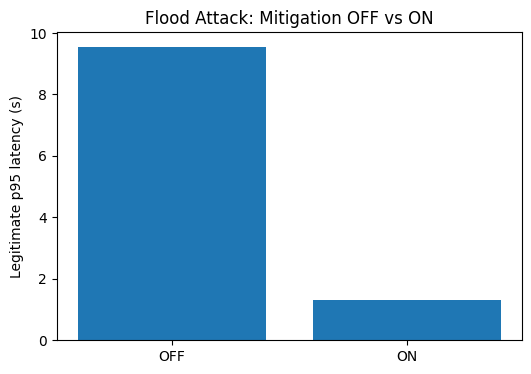

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(results["mode"], results["legit_p95_s"])
plt.ylabel("Legitimate p95 latency (s)")
plt.title("Flood Attack: Mitigation OFF vs ON")

plt.savefig(
    "/content/DoS-Stress-Testing/flood_before_after.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [56]:
import pandas as pd

off_samples = pd.read_json(
    "runs/flood-off-8/gateway_samples.jsonl",
    lines=True
)

on_samples = pd.read_json(
    "runs/flood-on-fresh/gateway_samples.jsonl",
    lines=True
)

print("OFF max upstream waiting:", off_samples["upstream_waiting"].max())
print("ON max upstream waiting:", on_samples["upstream_waiting"].max())
print("ON max gateway inflight:", on_samples["gateway_inflight"].max())

OFF max upstream waiting: 1.0
ON max upstream waiting: 1.0
ON max gateway inflight: 5


In [58]:
%cd /content/DoS-Stress-Testing

!mkdir -p results

!cp /content/flood_before_after.csv results/flood_before_after.csv
!cp /content/DoS-Stress-Testing/flood_before_after.png results/flood_before_after.png

!ls -l results

/content/DoS-Stress-Testing
total 36
-rw-r--r-- 1 root root   157 Sep 11 16:42 flood_before_after.csv
-rw-r--r-- 1 root root 32140 Sep 11 16:42 flood_before_after.png


In [60]:
!git config --global user.email "mena.abdelmoneim04@gmail.com"
!git config --global user.name "mena-04"
!git add results/
!git commit -m "Add flood mitigation results and chart"
!git push origin main

[main bdaf010] Add flood mitigation results and chart
 2 files changed, 3 insertions(+)
 create mode 100644 results/flood_before_after.csv
 create mode 100644 results/flood_before_after.png
fatal: could not read Username for 'https://github.com': No such device or address
